# 01 — Exploration des données
Dataset : `freelancer_job_postings.csv` — 9 193 projets

In [12]:
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (12, 5)
%matplotlib inline

## 1. Chargement du CSV (format imbriqué)

In [13]:
COLS = ['projectId','job_title','job_description','tags','client_state',
        'client_country','client_average_rating','client_review_count',
        'min_price','max_price','avg_price','currency','rate_type']

rows = []
with open('../freelancer_job_postings.csv', encoding='utf-8', errors='replace') as f:
    for i, raw in enumerate(f):
        if i == 0: continue
        line = raw.strip()
        while line.endswith(';'): line = line[:-1]
        if line.startswith('"') and line.endswith('"'):
            line = line[1:-1].replace('""', '"')
        parts = list(csv.reader([line]))[0]
        if len(parts) >= 13:
            rows.append(parts[:13])

df = pd.DataFrame(rows, columns=COLS)

# Types
for col in ['client_average_rating','client_review_count','min_price','max_price','avg_price']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df.shape)
df.head(3)

(9193, 13)


,projectId,job_title,job_description,tags,client_state,client_country,client_average_rating,client_review_count,min_price,max_price,avg_price,currency,rate_type
0,37426471,development and implementation of a federated ...,please bid only if you are ready to do the wor...,"['algorithm', 'java', 'python', 'machine learn...",Heilbronn,Germany,5.0,17.0,8.0,30.0,19.0,EUR,fixed
1,37421546,Data Entry -- 2,Project Title: Data Entry - Data Analysis in E...,"['excel', 'statistical analysis', 'statistics'...",Nagpur,India,0.0,0.0,750.0,1250.0,1000.0,INR,hourly
2,37400492,Data Scrap,I am looking for a freelancer who can help me ...,"['web scraping', 'data mining', 'data entry', ...",Eaubonne,France,5.0,1.0,30.0,250.0,140.0,EUR,fixed


## 2. Aperçu général

In [14]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 9193 entries, 0 to 9192
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   projectId              9193 non-null   str    
 1   job_title              9193 non-null   str    
 2   job_description        9193 non-null   str    
 3   tags                   9193 non-null   str    
 4   client_state           9193 non-null   str    
 5   client_country         9193 non-null   str    
 6   client_average_rating  8946 non-null   float64
 7   client_review_count    8986 non-null   float64
 8   min_price              9015 non-null   float64
 9   max_price              9030 non-null   float64
 10  avg_price              9063 non-null   float64
 11  currency               9193 non-null   str    
 12  rate_type              9193 non-null   str    
dtypes: float64(5), str(8)
memory usage: 933.8 KB


,client_average_rating,client_review_count,min_price,max_price,avg_price
count,8946.000000,8986.000000,9.015000e+03,9.030000e+03,9.063000e+03
mean,2.422267,21.058702,2.973235e+03,6.870024e+03,4.933842e+03
std,2.472668,87.994089,2.870384e+04,5.381239e+04,4.057527e+04
min,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000,0.000000,1.000000e+01,3.000000e+01,2.000000e+01
50%,0.000000,0.000000,3.000000e+01,2.500000e+02,1.400000e+02
75%,5.000000,5.000000,6.000000e+02,1.500000e+03,1.048500e+03
max,5.000000,969.000000,1.200000e+06,2.500000e+06,1.750000e+06


## 3. Valeurs manquantes

In [15]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.concat([missing, missing_pct], axis=1, keys=['count','%'])

,count,%
client_average_rating,247,2.69
client_review_count,207,2.25
min_price,178,1.94
max_price,163,1.77
avg_price,130,1.41
client_state,0,0.00
tags,0,0.00
job_description,0,0.00
job_title,0,0.00
projectId,0,0.00


## 4. Distribution des prix

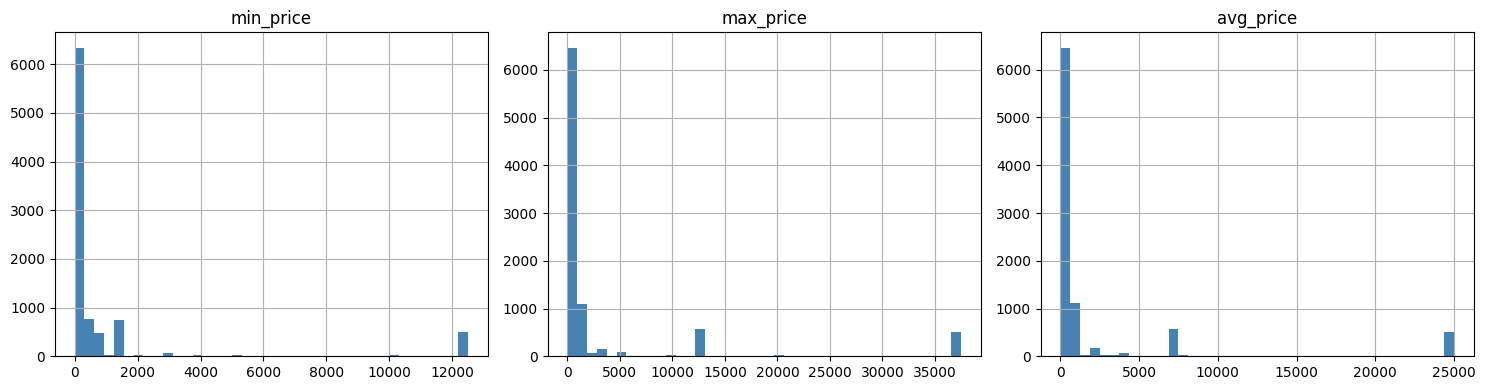

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, ['min_price','max_price','avg_price']):
    df[col].dropna().clip(upper=df[col].quantile(0.95)).hist(bins=40, ax=ax, color='steelblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 5. Type de tarification

C:\Users\pc\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\pc\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 61623 (\uf0b7) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


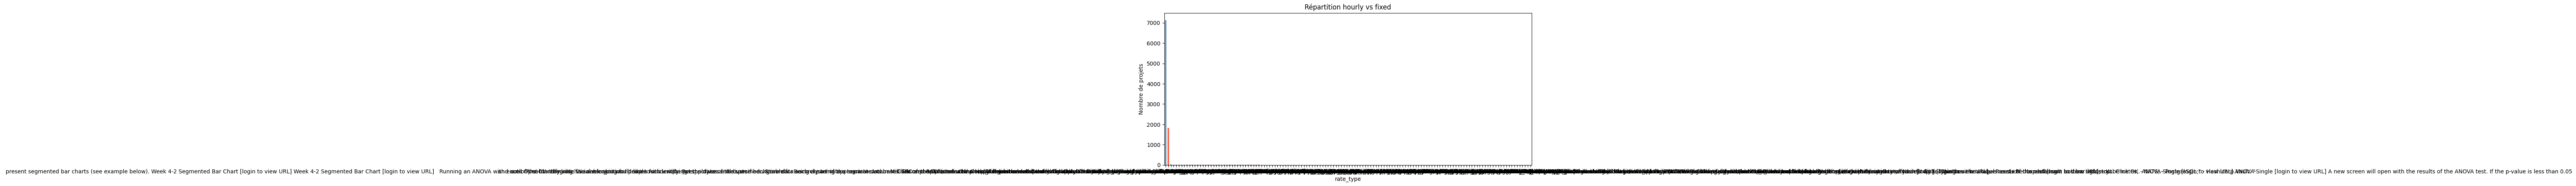

In [17]:
df['rate_type'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Répartition hourly vs fixed')
plt.ylabel('Nombre de projets')
plt.xticks(rotation=0)
plt.show()

## 6. Top 15 pays clients

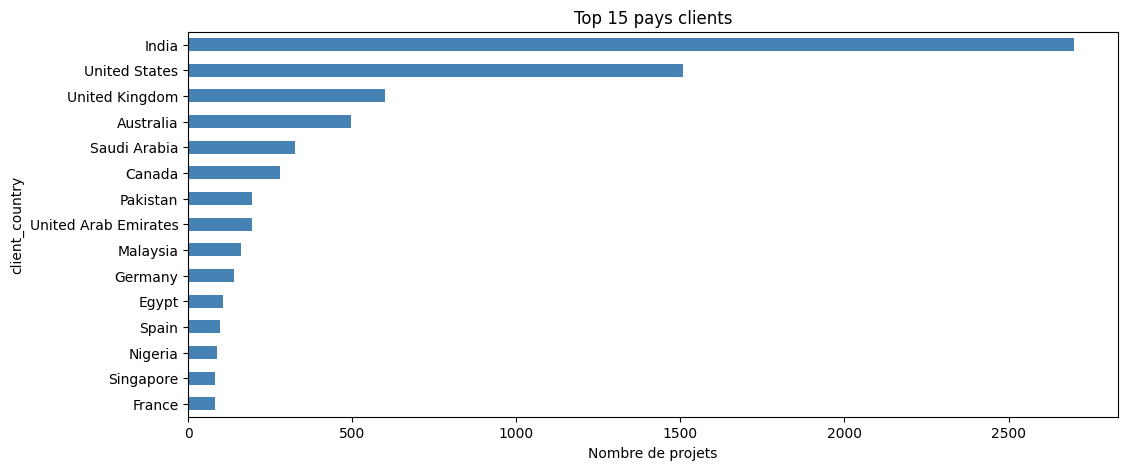

In [18]:
df['client_country'].value_counts().head(15).plot(kind='barh', color='steelblue')
plt.title('Top 15 pays clients')
plt.xlabel('Nombre de projets')
plt.gca().invert_yaxis()
plt.show()

## 7. Distribution des ratings clients

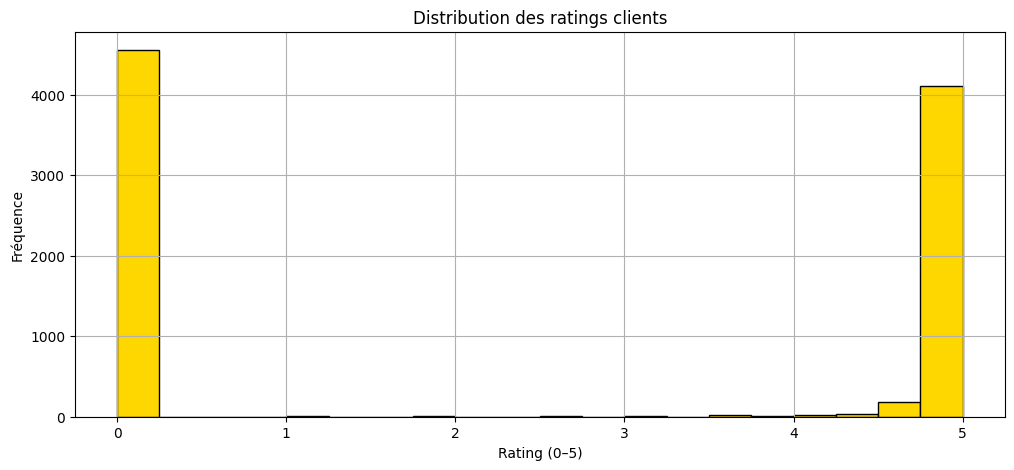

Rating moyen : 2.42


In [19]:
df['client_average_rating'].hist(bins=20, color='gold', edgecolor='black')
plt.title('Distribution des ratings clients')
plt.xlabel('Rating (0–5)')
plt.ylabel('Fréquence')
plt.show()
print('Rating moyen :', df['client_average_rating'].mean().round(2))

## 8. Tags les plus fréquents

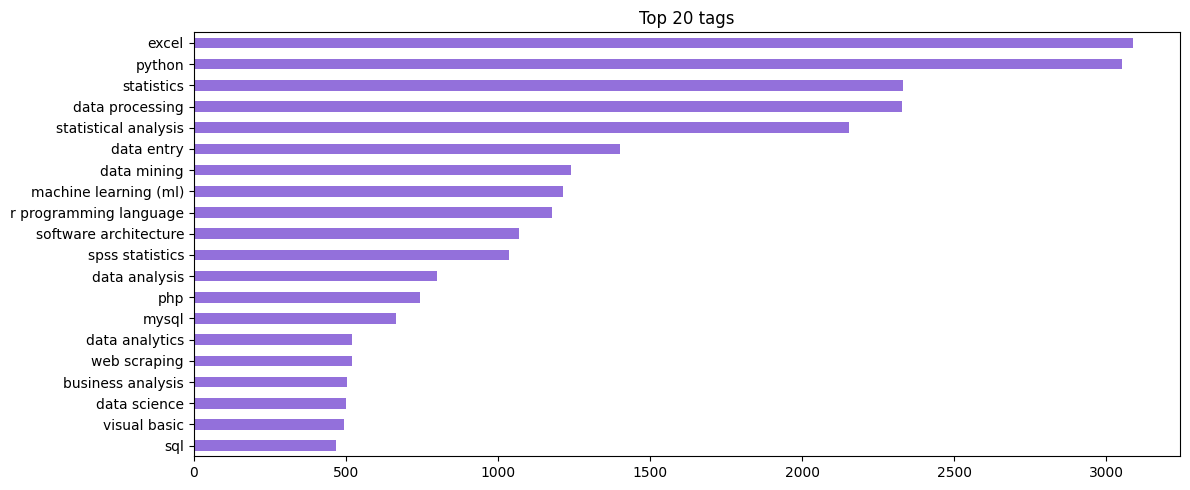

In [20]:
from collections import Counter

all_tags = []
for t in df['tags'].dropna():
    cleaned = str(t).strip("[]").replace("'", "")
    all_tags.extend([x.strip() for x in cleaned.split(',') if x.strip()])

top_tags = pd.Series(Counter(all_tags)).sort_values(ascending=False).head(20)
top_tags.plot(kind='barh', color='mediumpurple')
plt.title('Top 20 tags')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Corrélations

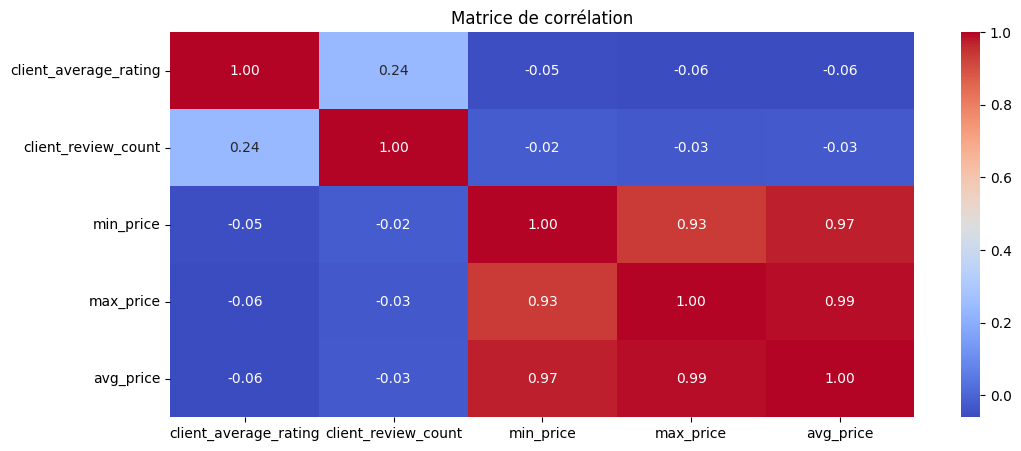

In [21]:
import seaborn as sns
corr = df[['client_average_rating','client_review_count','min_price','max_price','avg_price']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matrice de corrélation')
plt.show()

## 10. Sauvegarde du DataFrame brut

In [22]:
df.to_csv('../data/raw.csv', index=False)
print('Sauvegardé → data/raw.csv')

Sauvegardé → data/raw.csv
